# 01 Exploration — B12
Week-2 rule: build nothing, just look. Runs on `data/raw/` if present, else the synthetic files (**synthetic results are not findings**).

In [1]:
import os, sys
import pandas as pd, matplotlib.pyplot as plt
root = os.getcwd()
while not os.path.isdir(os.path.join(root, 'src')):
    root = os.path.dirname(root)
os.chdir(root); sys.path.insert(0, 'src')
from data_loader import find_checkpoints
folder = os.path.dirname(find_checkpoints()[0])
print('using', folder)
matches = pd.read_csv(f'{folder}/matches.csv', dtype={'match_id': str})
deliveries = pd.read_csv(f'{folder}/deliveries.csv', dtype={'match_id': str})
cp = pd.read_csv(f'{folder}/checkpoints.csv', dtype={'match_id': str})

using data/processed


In [2]:
for n, d in [('matches', matches), ('deliveries', deliveries), ('checkpoints', cp)]:
    print(n, d.shape); print(d.dtypes.to_string()); print('missing:'); print(d.isna().sum().to_string()); print()

matches (383, 11)
match_id                  str
series_id                 str
date                      str
position_in_series    float64
team_a                    str
team_b                    str
venue                 float64
toss_winner               str
winner                    str
margin_runs           float64
margin_wickets        float64
missing:
match_id                0
series_id             124
date                    0
position_in_series    383
team_a                  0
team_b                  0
venue                 383
toss_winner            10
winner                  4
margin_runs           190
margin_wickets        197

deliveries (91778, 13)
match_id            str
innings           int64
over              int64
ball              int64
batting_team        str
bowling_team        str
striker         float64
non_striker     float64
bowler          float64
runs_batter       int64
runs_extras       int64
wicket            int64
wicket_type     float64
missing:
match_id    

## Checkpoints per over_mark (innings that ended early have no later checkpoint)

In [3]:
print(cp.groupby('over_mark').size())
print(cp.groupby(['over_mark', 'innings']).size().unstack())

over_mark
6     766
10    766
12    766
15    756
dtype: int64
innings      1    2
over_mark          
6          383  383
10         383  383
12         383  383
15         383  373


## Target distribution

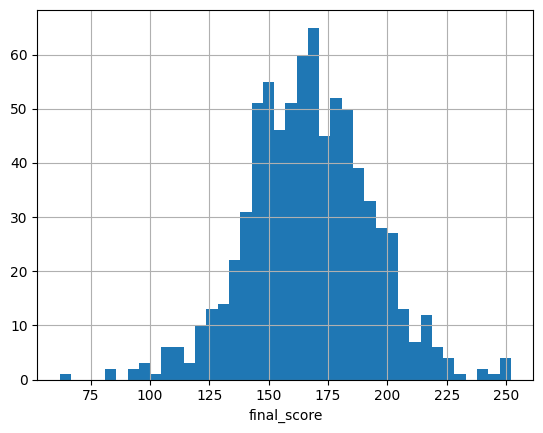

In [4]:
cp.drop_duplicates(['match_id', 'innings'])['final_score'].hist(bins=40); plt.xlabel('final_score'); plt.show()

## Over-by-over pattern (runs per over from deliveries)

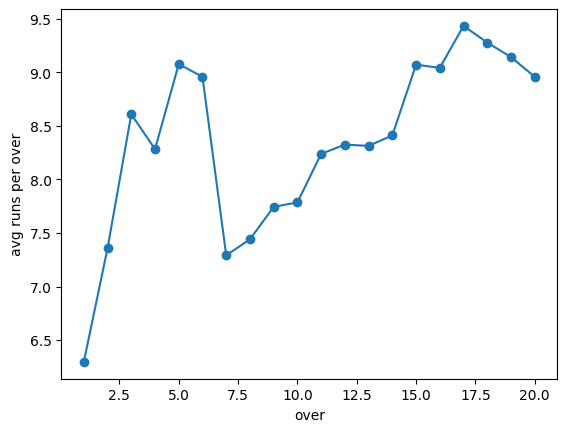

In [5]:
deliveries['runs'] = deliveries['runs_batter'] + deliveries['runs_extras']
deliveries.groupby('over')['runs'].sum().div(deliveries['match_id'].nunique() * 2).plot(marker='o'); plt.ylabel('avg runs per over'); plt.show()

## Predictor vs target at each checkpoint

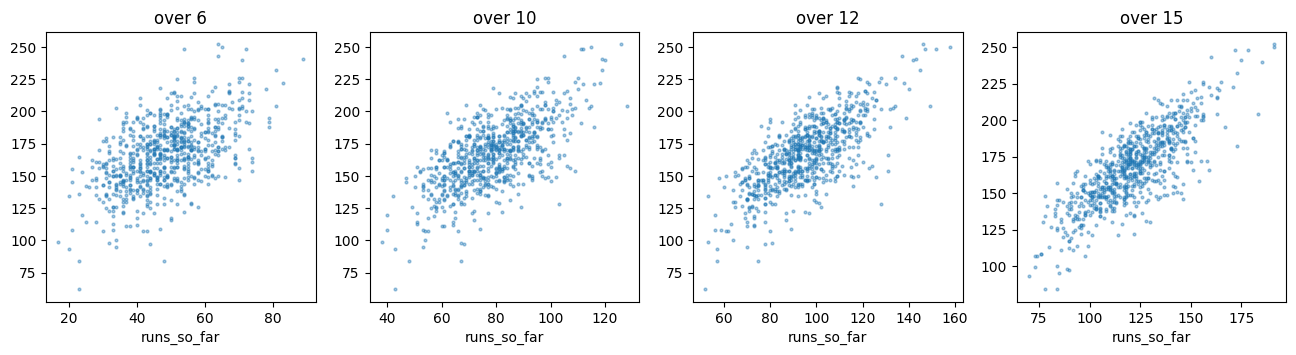

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3.5))
for a, om in zip(ax, [6, 10, 12, 15]):
    d = cp[cp.over_mark == om]; a.scatter(d['runs_so_far'], d['final_score'], s=4, alpha=.4); a.set_title(f'over {om}'); a.set_xlabel('runs_so_far')
plt.show()

## Collinearity check
`current_run_rate` should equal runs_so_far / over_mark. If so SHAP will split credit between them.

In [7]:
cp['rr_check'] = (cp['runs_so_far'] / cp['over_mark'] - cp['current_run_rate']).abs()
print(cp['rr_check'].describe())
print(cp[['runs_so_far','wickets_down','current_run_rate','balls_since_boundary','final_score']].corr().round(2))

count    3054.000000
mean        0.001681
std         0.001667
min         0.000000
25%         0.000000
50%         0.003333
75%         0.003333
max         0.003333
Name: rr_check, dtype: float64
                      runs_so_far  wickets_down  current_run_rate  \
runs_so_far                  1.00          0.17              0.48   
wickets_down                 0.17          1.00             -0.44   
current_run_rate             0.48         -0.44              1.00   
balls_since_boundary        -0.07          0.27             -0.32   
final_score                  0.36         -0.44              0.66   

                      balls_since_boundary  final_score  
runs_so_far                          -0.07         0.36  
wickets_down                          0.27        -0.44  
current_run_rate                     -0.32         0.66  
balls_since_boundary                  1.00        -0.24  
final_score                          -0.24         1.00  


## Things we did not expect
Generated list in `docs/observations.md` (re-run `make report`). Add your own after reading the plots above.